# Lab 05 — Image Segmentation (AI-4002)
| Section | What's inside |
|---|---|
| 0 | Setup — sample images in `data/` (document, coins, colored objects, part, brain phantom, touching coins, cat) |
| A | Manual quick reference: global · adaptive · Otsu · color (HSV) · hysteresis/Canny · region growing · watershed · K-means |
| T1 | Uneven-light document: 3 global thresholds vs adaptive |
| T2 | Adaptive strategy: blockSize × C × Mean/Gaussian |
| T3 | Otsu quality control (+ histogram, preprocessing effect) |
| T4 | Color sorting with HSV (restrictive vs final mask) |
| T5 | Canny boundaries with 3 threshold pairs |
| T6 | Region growing on brain MRI (3 thresholds, 2 seeds) |
| T7 | Marker-based watershed (10 stages) |
| T8 | Tuning the distance-transform threshold (table) |
| T9 | K-Means with K = 2, 4, 6 |
| T10 | Unknown image: 3 methods compared + conclusion |

**Rules from the task sheet:** OpenCV + NumPy only (no prebuilt segmentation/DL), show original + result, record & justify parameters, save every output (`output/`).

## 0. Setup — sample images

In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from collections import deque
from skimage import data                     # only to create sample files
os.makedirs('data', exist_ok=True); os.makedirs('output', exist_ok=True)
rng = np.random.default_rng(0)
yy, xx = np.mgrid[0:300, 0:400]

if not os.path.exists('data/document.png'):
    cv2.imwrite('data/document.png', cv2.resize(data.page(), None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC))
if not os.path.exists('data/coins.png'):
    cv2.imwrite('data/coins.png', data.coins())
if not os.path.exists('data/objects.png'):                       # colored objects incl. a yellow car
    img = np.zeros((300, 400, 3), np.uint8); img[:] = (150, 150, 150)
    cv2.rectangle(img, (40, 150), (200, 220), (0, 220, 240), -1); cv2.rectangle(img, (80, 110), (170, 150), (0, 220, 240), -1)
    cv2.circle(img, (80, 225), 18, (30, 30, 30), -1); cv2.circle(img, (165, 225), 18, (30, 30, 30), -1)   # wheels
    cv2.circle(img, (290, 80), 40, (40, 40, 220), -1); cv2.rectangle(img, (250, 170), (360, 260), (200, 80, 30), -1)
    cv2.circle(img, (330, 120), 22, (60, 200, 60), -1)
    shade = (0.55 + 0.45 * (xx / 400.0))[..., None]              # light from the right -> left side darker
    img = np.clip(img * shade + rng.normal(0, 6, img.shape), 0, 255).astype(np.uint8)
    cv2.imwrite('data/objects.png', img)
if not os.path.exists('data/part.png'):                          # mechanical part, uneven light -> strong + weak edges
    part = np.full((300, 400), 60, np.float32)
    cv2.circle(part, (200, 150), 110, 170, -1)
    for a in range(0, 360, 30):
        cx, cy = 200 + 118 * np.cos(np.deg2rad(a)), 150 + 118 * np.sin(np.deg2rad(a))
        cv2.circle(part, (int(cx), int(cy)), 14, 170, -1)        # teeth
    cv2.circle(part, (200, 150), 35, 60, -1)
    for a in (45, 135, 225, 315): cv2.circle(part, (int(200 + 70*np.cos(np.deg2rad(a))), int(150 + 70*np.sin(np.deg2rad(a)))), 12, 120, -1)  # weak-contrast holes
    part = part * (0.6 + 0.4 * xx / 400) + rng.normal(0, 8, part.shape)
    cv2.imwrite('data/part.png', np.clip(part, 0, 255).astype(np.uint8))
if not os.path.exists('data/brain_mri.png'):                    # brain-like phantom
    def ell(cx, cy, a, b): return ((xx-cx)/a)**2 + ((yy-cy)/b)**2 <= 1
    b = np.zeros((300, 400), np.float32)
    b[ell(200, 150, 150, 125)] = 200; b[ell(200, 150, 140, 115)] = 110        # skull + brain
    b[ell(170, 140, 22, 45)] = 40; b[ell(230, 140, 22, 45)] = 40              # ventricles
    b[ell(260, 210, 30, 22)] = 175                                            # lesion (target)
    b[ell(120, 90, 25, 18)] = 175                                             # separate area with SAME intensity
    b = cv2.GaussianBlur(b, (7, 7), 0) + rng.normal(0, 7, b.shape)
    cv2.imwrite('data/brain_mri.png', np.clip(b, 0, 255).astype(np.uint8))
if not os.path.exists('data/touching_coins.png'):
    tc = np.full((300, 400), 70, np.float32)
    for (cx, cy, r) in [(90, 90, 45), (165, 100, 42), (240, 85, 40), (120, 190, 48), (205, 185, 44), (290, 190, 46), (330, 100, 38)]:
        cv2.circle(tc, (cx, cy), r, 190, -1)
    tc = cv2.GaussianBlur(tc, (5, 5), 0) + rng.normal(0, 10, tc.shape)
    cv2.imwrite('data/touching_coins.png', cv2.cvtColor(np.clip(tc, 0, 255).astype(np.uint8), cv2.COLOR_GRAY2BGR))
if not os.path.exists('data/wildlife.png'):
    cv2.imwrite('data/wildlife.png', cv2.cvtColor(data.chelsea(), cv2.COLOR_RGB2BGR))
print(sorted(os.listdir('data')))

def show(images, titles, cols=None, size=4):
    cols = cols or len(images); rows = int(np.ceil(len(images) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(size * cols, size * 0.8 * rows)); ax = np.array(ax).ravel()
    for a in ax: a.axis('off')
    for a, im, t in zip(ax, images, titles):
        a.imshow(im if im.ndim == 2 else cv2.cvtColor(im, cv2.COLOR_BGR2RGB), cmap='gray' if im.ndim == 2 else None); a.set_title(t, fontsize=10)
    plt.tight_layout(); plt.show()

['brain_mri.png', 'coins.png', 'document.png', 'objects.png', 'part.png', 'touching_coins.png', 'wildlife.png']


## A. Manual quick reference (copy-ready)
| Method | Idea | Use when |
|---|---|---|
| Global | one T for whole image | clear intensity difference |
| Adaptive | T per neighbourhood (mean/Gaussian − C) | varying lighting |
| Otsu | auto T maximizing **inter-class variance** | **bimodal** histogram |
| Color (HSV) | `inRange(lower, upper)` | distinct colors |
| Hysteresis (Canny) | high T = strong, low T links weak | boundaries |
| Region growing | grow from seed while similar | uniform regions |
| Watershed | topographic flooding from markers | **touching/overlapping** objects |
| K-Means | cluster pixel features | complex color images |

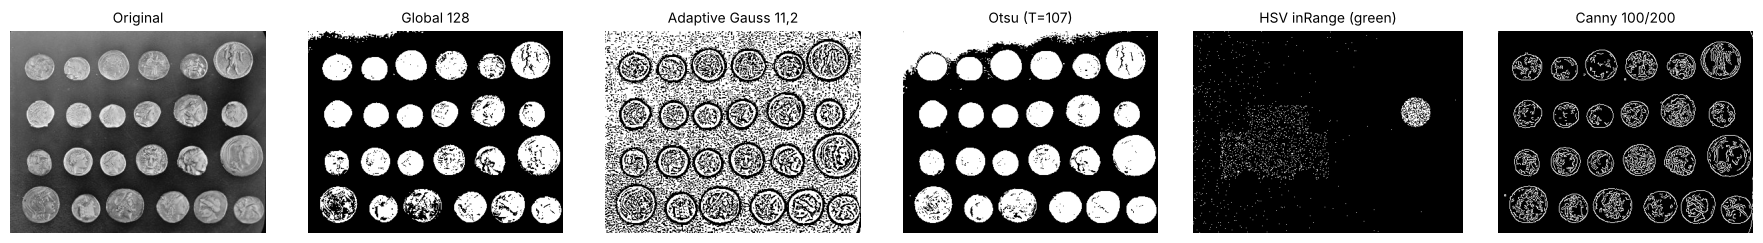

In [2]:
gray = cv2.imread('data/coins.png', cv2.IMREAD_GRAYSCALE)
_, glob   = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)
adapt     = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
T_otsu, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)   # T ignored, returned
hsv  = cv2.cvtColor(cv2.imread('data/objects.png'), cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv, np.array([30, 50, 50]), np.array([60, 255, 255]))          # manual's green range
edges = cv2.Canny(gray, 100, 200)
show([gray, glob, adapt, otsu, mask, edges], ['Original', 'Global 128', 'Adaptive Gauss 11,2', f'Otsu (T={T_otsu:.0f})', 'HSV inRange (green)', 'Canny 100/200'], cols=6, size=3)

# T1 — Document Under Uneven Lighting
Global with 3 thresholds vs adaptive. Output: **Original → Global T1 → T2 → T3 → Adaptive**.

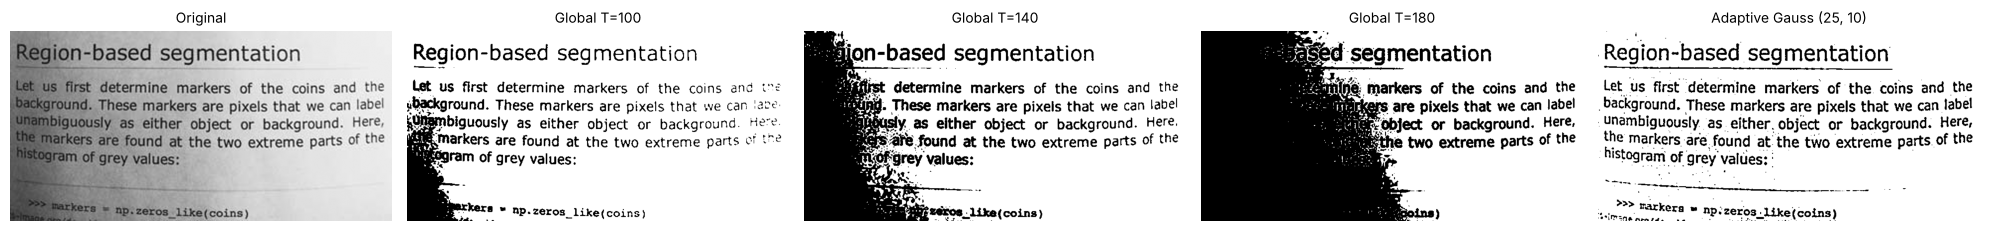

T=100: black pixels left half 22% | right half 5%
T=140: black pixels left half 48% | right half 8%
T=180: black pixels left half 87% | right half 12%
Adaptive: left 16% | right 10%


In [3]:
doc = cv2.imread('data/document.png', cv2.IMREAD_GRAYSCALE)
if doc is None: raise FileNotFoundError('data/document.png')
Ts = [100, 140, 180]
globals_ = [cv2.threshold(doc, t, 255, cv2.THRESH_BINARY)[1] for t in Ts]
adaptive = cv2.adaptiveThreshold(doc, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 25, 10)
show([doc] + globals_ + [adaptive], ['Original'] + [f'Global T={t}' for t in Ts] + ['Adaptive Gauss (25, 10)'], cols=5, size=4)
for t, g in zip(Ts, globals_): cv2.imwrite(f'output/T1_global_{t}.png', g)
cv2.imwrite('output/T1_adaptive.png', adaptive)

# where does global fail? compare left (dark) vs right (bright) halves
h, w = doc.shape
for t, g in zip(Ts, globals_):
    print(f'T={t}: black pixels left half {np.mean(g[:, :w//2] == 0):.0%} | right half {np.mean(g[:, w//2:] == 0):.0%}')
print(f'Adaptive: left {np.mean(adaptive[:, :w//2] == 0):.0%} | right {np.mean(adaptive[:, w//2:] == 0):.0%}')

**Parameters:** global T = 100/140/180 (low, mid, high); adaptive Gaussian, blockSize = 25 (≈ larger than a letter stroke), C = 10 (cleans paper noise).
**Where global fails:** the darker side of the page — a high T turns shaded paper black (unwanted regions), a low T loses text in the bright side or keeps only part of it.
**Why a single threshold struggles:** the same paper has different brightness in different places, so no one value separates text from paper everywhere; adaptive thresholding compares each pixel only with its **local** neighbourhood, which shares the same lighting.

# T2 — Choosing the Adaptive Strategy (blockSize × C × method)

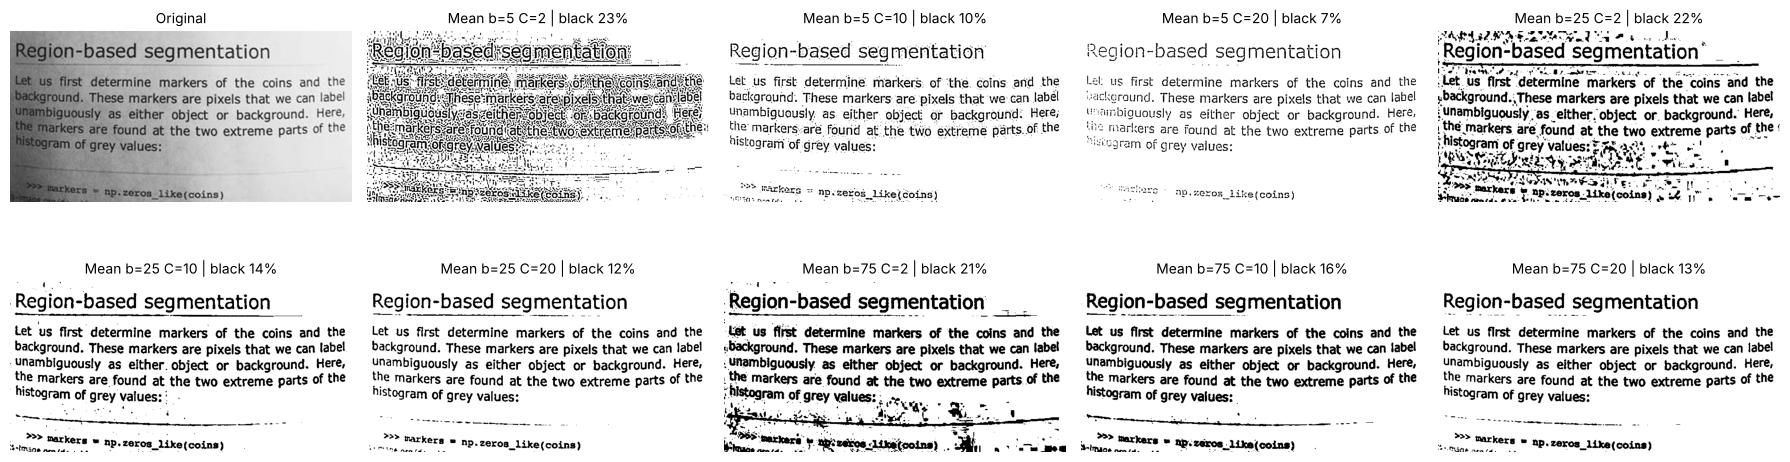

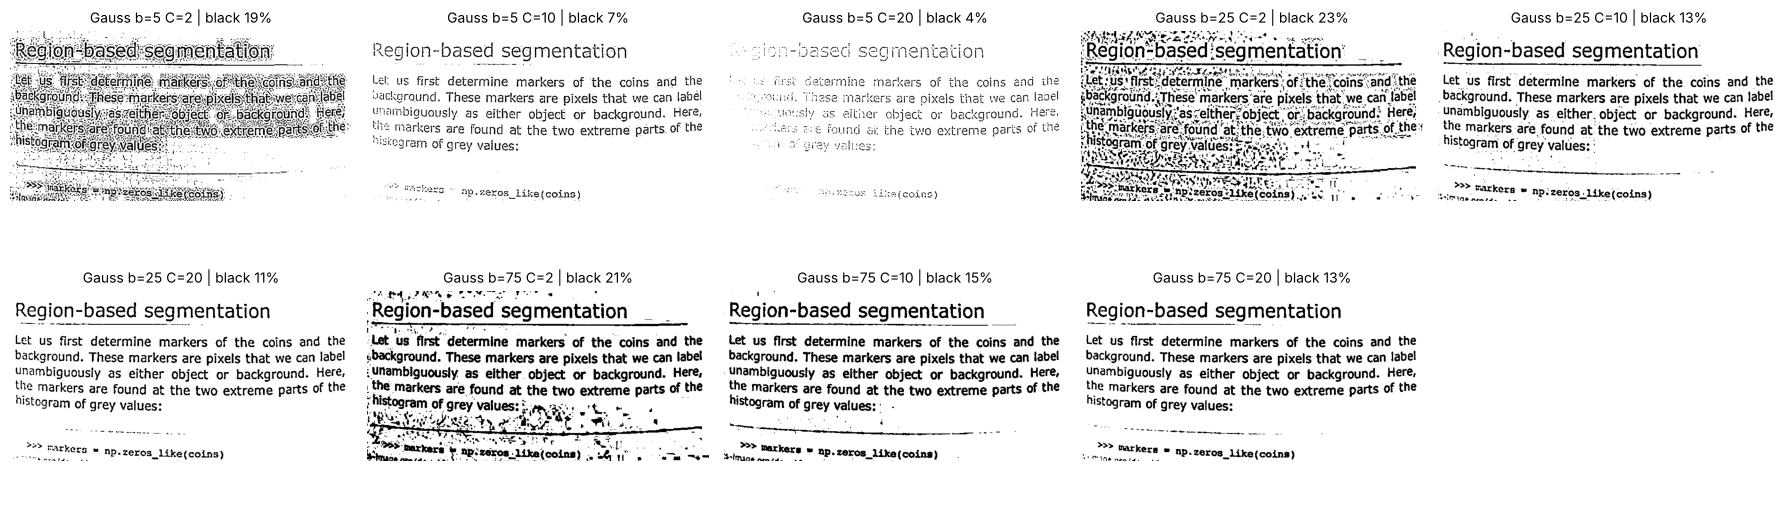

In [4]:
blocks, Cs = [5, 25, 75], [2, 10, 20]
results, titles = [], []
for method, name in [(cv2.ADAPTIVE_THRESH_MEAN_C, 'Mean'), (cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 'Gauss')]:
    for b in blocks:
        for C in Cs:
            r = cv2.adaptiveThreshold(doc, 255, method, cv2.THRESH_BINARY, b, C)
            results.append(r); titles.append(f'{name} b={b} C={C} | black {np.mean(r == 0):.0%}')
            cv2.imwrite(f'output/T2_{name}_b{b}_C{C}.png', r)
show([doc] + results[:9], ['Original'] + titles[:9], cols=5, size=3.6)
show(results[9:], titles[9:], cols=5, size=3.6)

**Analysis:**
1. **Neighbourhood too small (b=5):** window is smaller than a letter → letter interiors look like "background" → **broken / hollow characters**, noisy.
2. **Too large (b=75):** window spans lit and shaded areas → behaves like global thresholding → dark-side noise/blotches return.
3. **Increasing C:** T = local mean − C gets lower → fewer pixels become black → **less noise** but thin strokes may disappear if C is too big.
4. **Cleanest:** medium block (~25) with C ≈ 10.
5. **Gaussian vs Mean:** Gaussian weights the centre more → smoother, slightly cleaner edges; usually the better choice here.

# T3 — Quality Control with Otsu
Otsu tries every T and picks the one that **maximizes between-class variance** σ²_B = w₀·w₁·(μ₀ − μ₁)².

original           -> Otsu threshold = 107
contrast x1.3      -> Otsu threshold = 119
Gaussian blur 5x5  -> Otsu threshold = 104
CLAHE              -> Otsu threshold = 120
manual Otsu threshold: 108


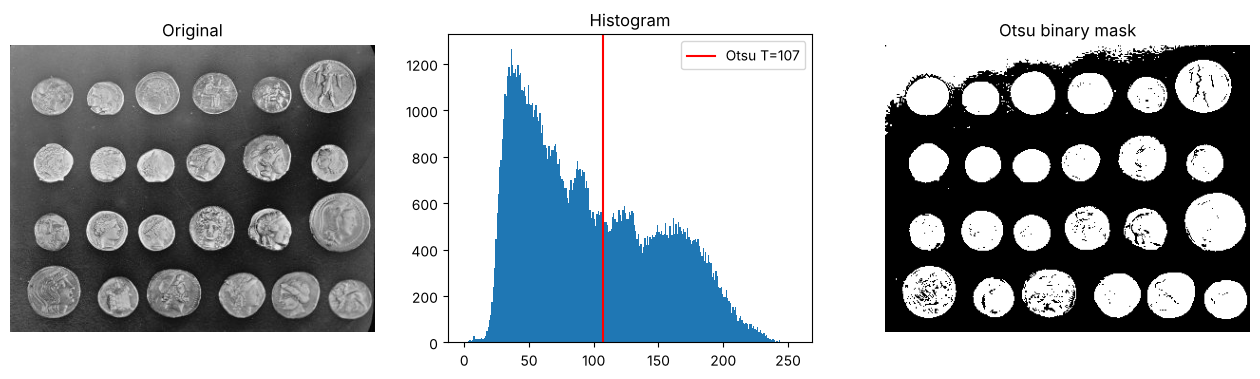

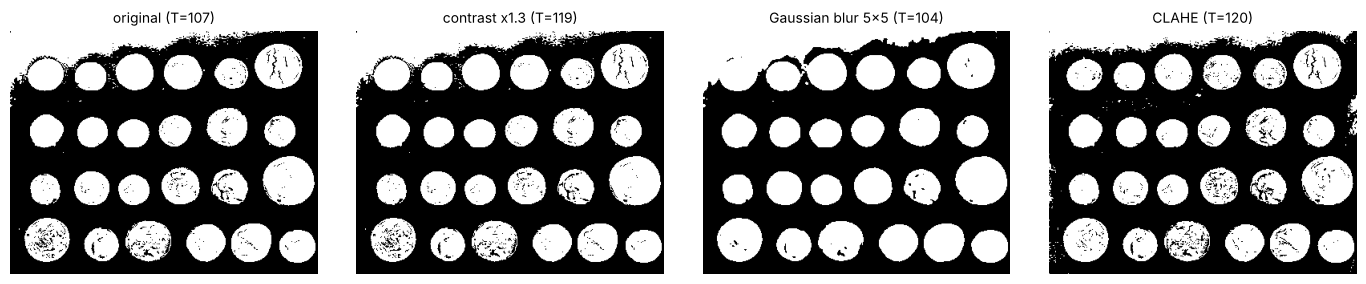

True

In [5]:
coins = cv2.imread('data/coins.png', cv2.IMREAD_GRAYSCALE)
T1, otsu1 = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# repeat after preprocessing: (a) contrast stretch  (b) Gaussian blur  (c) CLAHE
pre = {'contrast x1.3': cv2.convertScaleAbs(coins, alpha=1.3, beta=-20),
       'Gaussian blur 5x5': cv2.GaussianBlur(coins, (5, 5), 0),
       'CLAHE': cv2.createCLAHE(2.0, (8, 8)).apply(coins)}
res = {'original': (T1, otsu1)}
for k, im in pre.items(): res[k] = cv2.threshold(im, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
for k, (t, _) in res.items(): print(f'{k:18s} -> Otsu threshold = {t:.0f}')

# manual Otsu (to understand it)
hist = np.bincount(coins.ravel(), minlength=256).astype(float); p = hist / hist.sum()
best_t, best_var = 0, 0
for t in range(1, 256):
    w0, w1 = p[:t].sum(), p[t:].sum()
    if w0 == 0 or w1 == 0: continue
    mu0 = (np.arange(t) * p[:t]).sum() / w0; mu1 = (np.arange(t, 256) * p[t:]).sum() / w1
    var_b = w0 * w1 * (mu0 - mu1) ** 2
    if var_b > best_var: best_t, best_var = t, var_b
print('manual Otsu threshold:', best_t)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].imshow(coins, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].hist(coins.ravel(), bins=256, range=(0, 256)); ax[1].axvline(T1, color='r', label=f'Otsu T={T1:.0f}'); ax[1].legend(); ax[1].set_title('Histogram')
ax[2].imshow(otsu1, cmap='gray'); ax[2].set_title('Otsu binary mask'); ax[2].axis('off'); plt.show()
show([m for _, m in res.values()], [f'{k} (T={t:.0f})' for k, (t, _) in res.items()], size=3.5)
cv2.imwrite('output/T3_otsu.png', otsu1)

**Why Otsu helps:** the threshold is computed from each image's own histogram, so it adapts automatically when lighting/contrast changes (see how T moved after preprocessing) — no manual tuning per image. Works best when the histogram is **bimodal** (object + background).

# T4 — Sorting Objects by Color (HSV)

HSV at car centre (H,S,V): [ 30 255 156] | at shaded left end: [ 25 248 152]


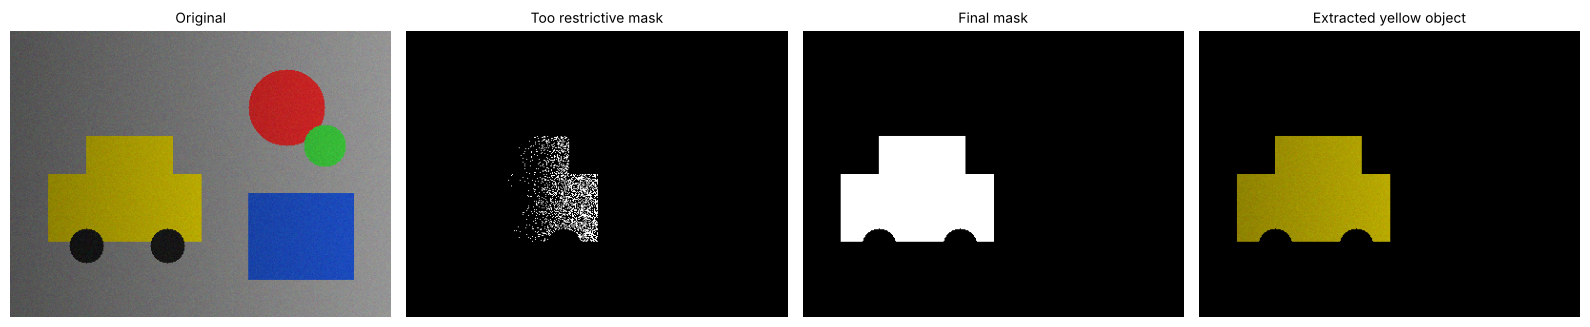

pixels captured: restrictive=1971, final=14379


In [6]:
img = cv2.imread('data/objects.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)               # OpenCV Hue range is 0-179
print('HSV at car centre (H,S,V):', hsv[180, 120], '| at shaded left end:', hsv[180, 50])

restrictive_lo, restrictive_hi = np.array([28, 200, 170]), np.array([32, 255, 255])   # too narrow S and V
final_lo, final_hi             = np.array([18, 100, 60]),  np.array([38, 255, 255])   # wider S/V, same hue band
m_restrict = cv2.inRange(hsv, restrictive_lo, restrictive_hi)
m_final = cv2.inRange(hsv, final_lo, final_hi)
m_final = cv2.morphologyEx(m_final, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))        # remove specks
extracted = cv2.bitwise_and(img, img, mask=m_final)
show([img, m_restrict, m_final, extracted], ['Original', 'Too restrictive mask', 'Final mask', 'Extracted yellow object'])
cv2.imwrite('output/T4_mask.png', m_final); cv2.imwrite('output/T4_extracted.png', extracted)
print(f'pixels captured: restrictive={int((m_restrict>0).sum())}, final={int((m_final>0).sum())}')

**Why the restrictive mask fails:** shading lowers **V** (brightness) and noise lowers **S** on the left part of the car, so those pixels fall outside a narrow S/V range even though their **Hue** is still yellow. HSV separates color (H) from brightness (V), so keep the hue band tight and the S/V range wide. Intensity alone cannot work because yellow and gray background can have similar gray levels.

# T5 — Boundary of a Manufactured Part (Canny hysteresis)

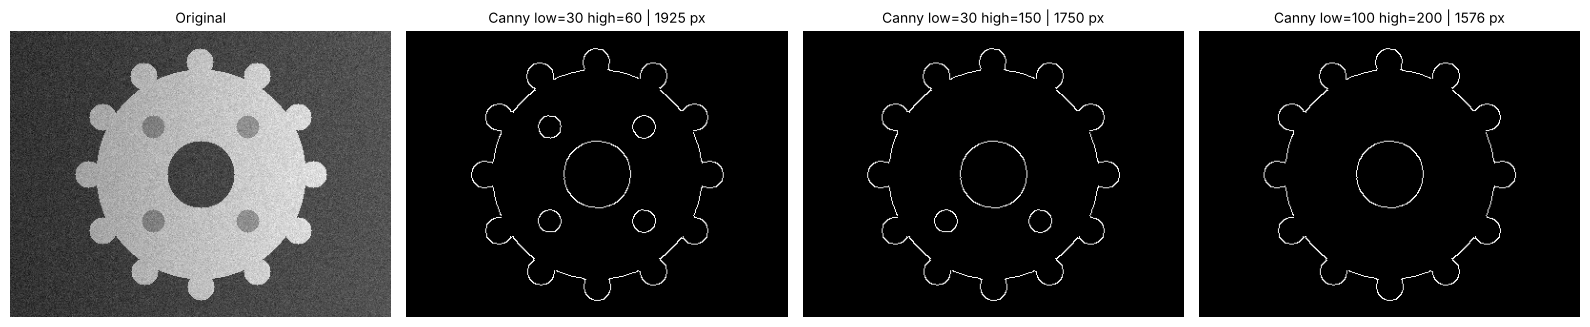

In [7]:
part = cv2.imread('data/part.png', cv2.IMREAD_GRAYSCALE)
blur = cv2.GaussianBlur(part, (5, 5), 1.4)
pairs = [(30, 60), (30, 150), (100, 200)]                      # low fixed then high raised; then both high
edge_maps = [cv2.Canny(blur, lo, hi) for lo, hi in pairs]
show([part] + edge_maps, ['Original'] + [f'Canny low={lo} high={hi} | {int((e>0).sum())} px' for (lo, hi), e in zip(pairs, edge_maps)])
for (lo, hi), e in zip(pairs, edge_maps): cv2.imwrite(f'output/T5_canny_{lo}_{hi}.png', e)

* **Strong edges:** outer rim/teeth on the bright right side — survive every pair (gradient > high).
* **Weak edges:** the low-contrast holes and the dim left side — kept only when connected to strong edges or when *high* is small.
* **Missing edges:** with (100, 200) the weak holes / left rim vanish.
* **Unwanted edges:** with (30, 60) noise speckles appear as tiny edges.
* **Effect:** raising **high** reduces the number of *seed* (strong) edges → fewer edges overall; raising **low** breaks chains (weak pixels no longer linked); too low = noise.

# T6 — Region Growing on a Brain MRI

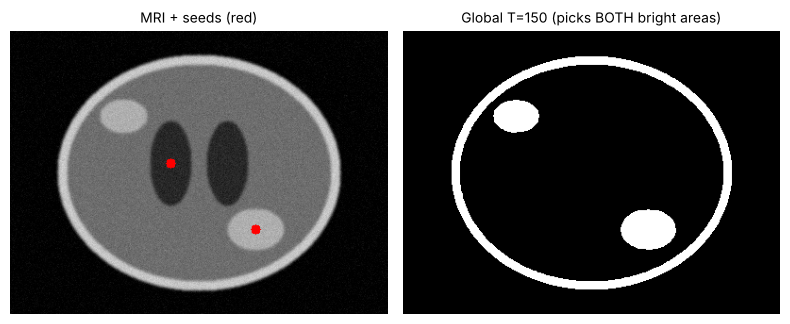

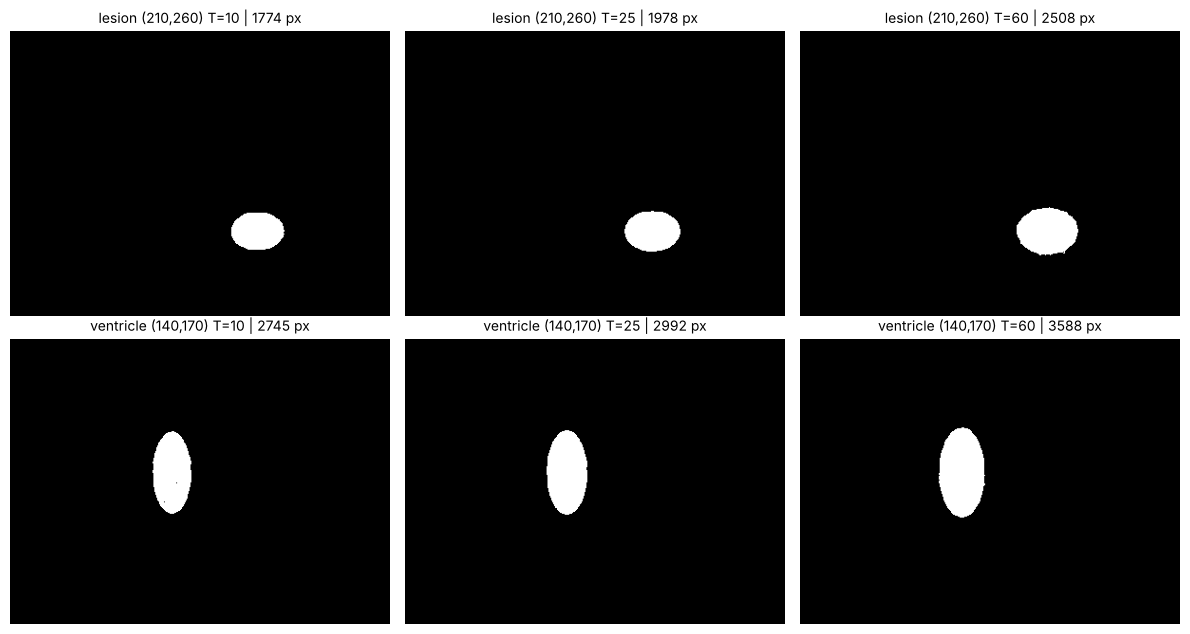

In [8]:
def region_growing(image, seed, threshold):
    '''seed = (row, col). 4-connected BFS; pixel joins if |I - I_seed| < threshold.'''
    h, w = image.shape
    mask = np.zeros_like(image, dtype=np.uint8)
    seed_val = int(image[seed])
    q = deque([seed])
    while q:
        r, c = q.popleft()
        if r < 0 or r >= h or c < 0 or c >= w or mask[r, c]: continue
        if abs(int(image[r, c]) - seed_val) < threshold:
            mask[r, c] = 255
            q.extend([(r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1)])
    return mask

mri = cv2.imread('data/brain_mri.png', cv2.IMREAD_GRAYSCALE)
mri_s = cv2.GaussianBlur(mri, (5, 5), 0)                    # small denoise so noise doesn't block growth
seeds = {'lesion (210,260)': (210, 260), 'ventricle (140,170)': (140, 170)}
ths = [10, 25, 60]
outs, titles = [], []
for name, sd in seeds.items():
    for t in ths:
        m = region_growing(mri_s, sd, t); outs.append(m); titles.append(f'{name} T={t} | {int((m>0).sum())} px')
        cv2.imwrite(f'output/T6_{name.split()[0]}_T{t}.png', m)
_, glob = cv2.threshold(mri_s, 150, 255, cv2.THRESH_BINARY)
vis = cv2.cvtColor(mri, cv2.COLOR_GRAY2BGR)
for sd in seeds.values(): cv2.circle(vis, sd[::-1], 5, (0, 0, 255), -1)
show([vis, glob], ['MRI + seeds (red)', 'Global T=150 (picks BOTH bright areas)'], size=4)
show(outs, titles, cols=3, size=4)

* T too small → region stops early (holes); T too large → **leaks** into neighbouring tissue.
* **Why the seed matters:** growth only spreads through *connected* pixels similar to the **seed's** intensity — a different seed has a different reference value and a different connected neighbourhood, so it grows a completely different structure (lesion vs ventricle). Global thresholding can't do this: it also selects the separate bright area with the same intensity.

# T7 — Marker-Based Watershed for Touching Coins
Stages: preprocessing → threshold → noise removal (opening) → sure background (dilate) → distance transform → sure foreground → unknown → marker labeling → watershed → boundaries.

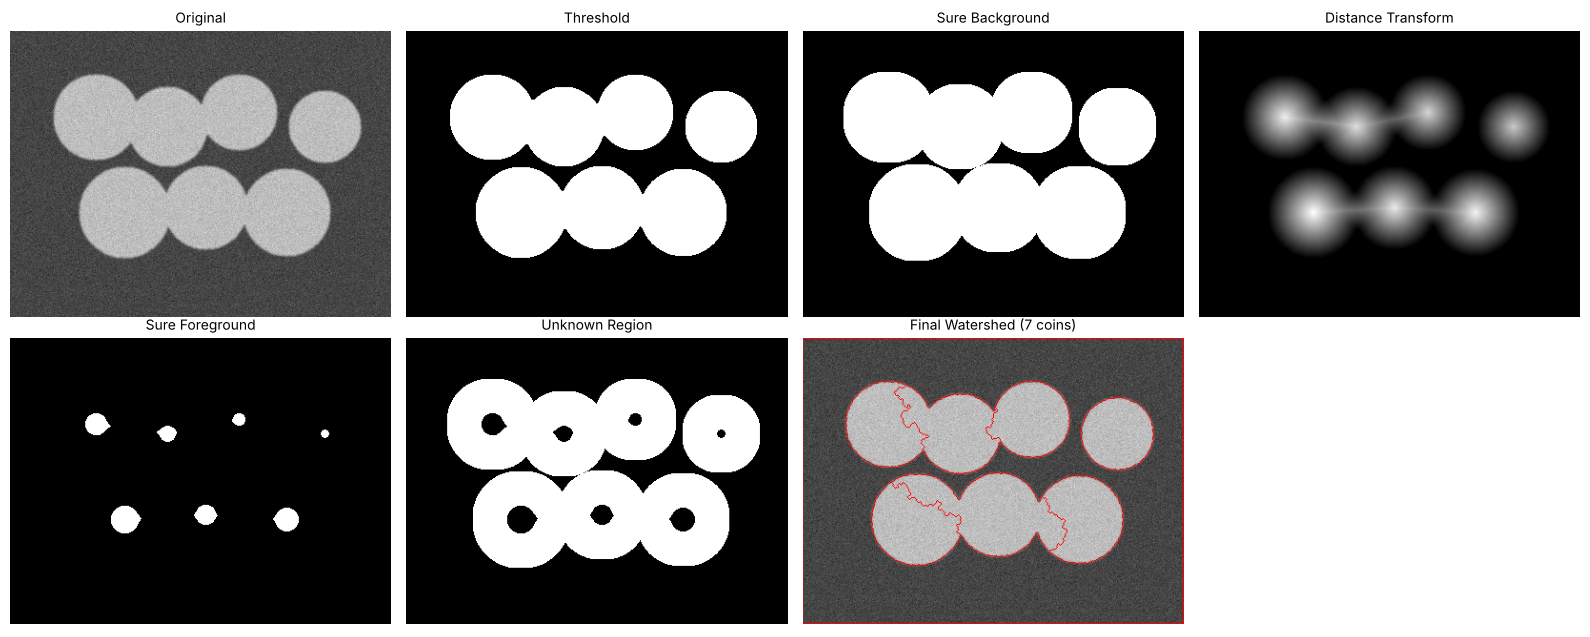

naive connected regions in threshold: 3 | watershed regions: 7


True

In [9]:
def watershed_pipeline(img_bgr, dist_ratio=0.5, show_steps=False):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)                                         # 1 preprocessing
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)     # 2 threshold (coins bright -> BINARY)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)         # 3 noise removal
    sure_bg = cv2.dilate(opening, kernel, iterations=3)                              # 4 sure background
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)                            # 5 distance transform
    _, sure_fg = cv2.threshold(dist, dist_ratio * dist.max(), 255, 0)                # 6 sure foreground
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)                                         # 7 unknown region
    n_markers, markers = cv2.connectedComponents(sure_fg)                            # 8 marker labeling
    markers = markers + 1                                                            #   background = 1, not 0
    markers[unknown == 255] = 0                                                      #   unknown = 0 -> to be flooded
    markers = cv2.watershed(img_bgr.copy(), markers)                                 # 9 watershed
    out = img_bgr.copy(); out[markers == -1] = [0, 0, 255]                           # 10 boundaries in red
    n_regions = len([l for l in np.unique(markers) if l > 1])
    steps = [img_bgr, thresh, sure_bg, cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8), sure_fg, unknown, out]
    return out, n_markers - 1, n_regions, steps

coins_bgr = cv2.imread('data/touching_coins.png')
final, n_fg, n_reg, steps = watershed_pipeline(coins_bgr, 0.7)   # 0.7 chosen from T8
show(steps, ['Original', 'Threshold', 'Sure Background', 'Distance Transform', 'Sure Foreground', 'Unknown Region', f'Final Watershed ({n_reg} coins)'], cols=4, size=4)
n_cc, _ = cv2.connectedComponents(steps[1]); print('naive connected regions in threshold:', n_cc - 1, '| watershed regions:', n_reg)
cv2.imwrite('output/T7_watershed.png', final)

Touching coins form one blob after thresholding (wrong count). The distance transform peaks at coin **centres**, so thresholding it gives one seed per coin; watershed floods from each seed and builds the red boundary where floods meet.

# T8 — Tuning the Distance-Transform Threshold

Exp Dist thr  FG markers  Regions  Observed result
1   0.1       3           3        merged: touching coins share a seed
2   0.3       3           3        merged: touching coins share a seed
3   0.5       6           6        merged: touching coins share a seed
4   0.6       7           7        good separation (7 coins)
5   0.7       7           7        good separation (7 coins)
6   0.8       6           6        small coins lost their seed / missed
7   0.9       4           4        small coins lost their seed / missed


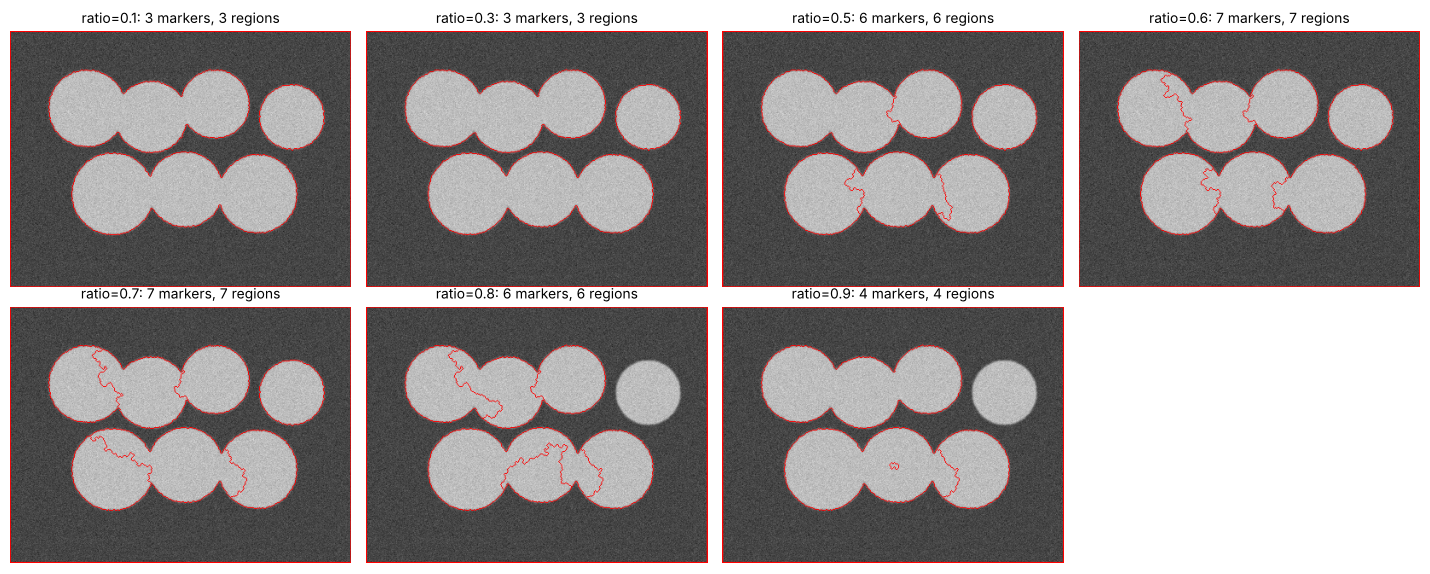

In [10]:
rows = []
outs, titles = [], []
for i, ratio in enumerate([0.1, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9], 1):
    out, n_fg, n_reg, _ = watershed_pipeline(coins_bgr, ratio)
    note = 'good separation (7 coins)' if n_fg == 7 else ('merged: touching coins share a seed' if ratio < 0.7 else 'small coins lost their seed / missed')
    rows.append((i, ratio, n_fg, n_reg, note)); outs.append(out); titles.append(f'ratio={ratio}: {n_fg} markers, {n_reg} regions')
print(f"{'Exp':<4}{'Dist thr':<10}{'FG markers':<12}{'Regions':<9}Observed result")
for r in rows: print(f'{r[0]:<4}{r[1]:<10}{r[2]:<12}{r[3]:<9}{r[4]}')
show(outs, titles, cols=4, size=3.6)

* **Low ratio (0.1):** sure-foreground blobs still touch → one marker for several coins → **merged**.
* **High ratio (0.8–0.9):** only the very centres survive; small coins may lose their marker or get split.
* **Best range here ≈ 0.6–0.7 × max distance** (the ratio that gives 7 markers = 7 coins; re-check the table for your image).

# T9 — K-Means Segmentation (K = 2, 4, 6)

K=2: colors 32584 -> 2 | mean abs diff from original = 17.3 | centres(BGR) = [[113, 135, 169], [56, 84, 122]]


K=4: colors 32584 -> 4 | mean abs diff from original = 11.1 | centres(BGR) = [[96, 122, 160], [26, 48, 82], [140, 154, 183], [62, 92, 132]]


K=6: colors 32584 -> 6 | mean abs diff from original = 8.9 | centres(BGR) = [[40, 69, 111], [87, 116, 154], [17, 34, 56], [152, 161, 186], [113, 136, 172], [65, 95, 134]]


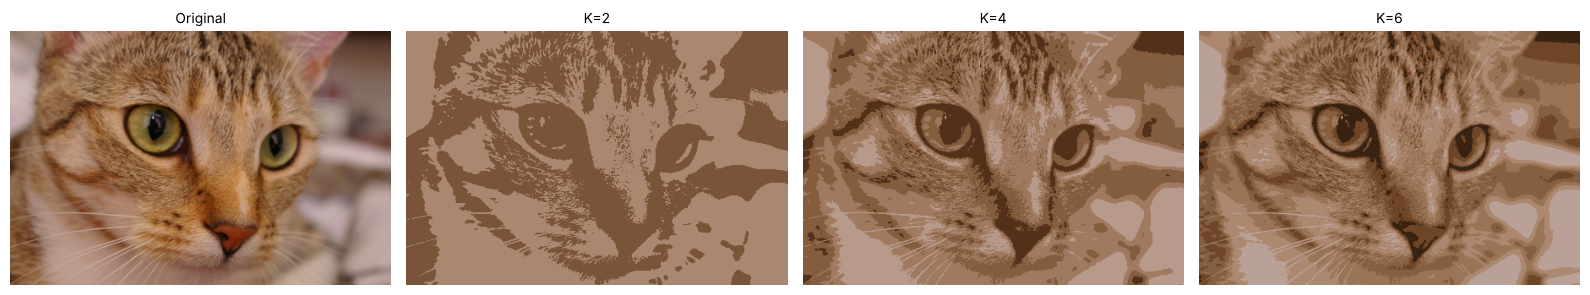

In [11]:
image = cv2.imread('data/wildlife.png')
pixel_values = np.float32(image.reshape((-1, 3)))          # N x 3 feature vectors, float32 required
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
outs, titles = [image], ['Original']
for K in [2, 4, 6]:
    compactness, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    seg = centers[labels.flatten()].reshape(image.shape)    # replace each pixel by its cluster centre
    outs.append(seg); titles.append(f'K={K}')
    n_orig = len(np.unique(pixel_values.astype(np.uint8), axis=0))
    print(f'K={K}: colors {n_orig} -> {K} | mean abs diff from original = {np.abs(seg.astype(int) - image).mean():.1f} | centres(BGR) = {centers.tolist()}')
    cv2.imwrite(f'output/T9_kmeans_K{K}.png', seg)
show(outs, titles, cols=4, size=4)

K=2 splits roughly light vs dark (cat vs background). K=4 separates fur shades and background. K=6 is close to the original: more clusters → less simplification, smaller difference from the original.

# T10 — Segmentation Engineer: Unknown Image (3 methods)

Otsu              : objects found = 24 (true = 24 coins)
Adaptive (51, -5) : objects found = 36 (true = 24 coins)
K-Means K=2       : objects found = 24 (true = 24 coins)


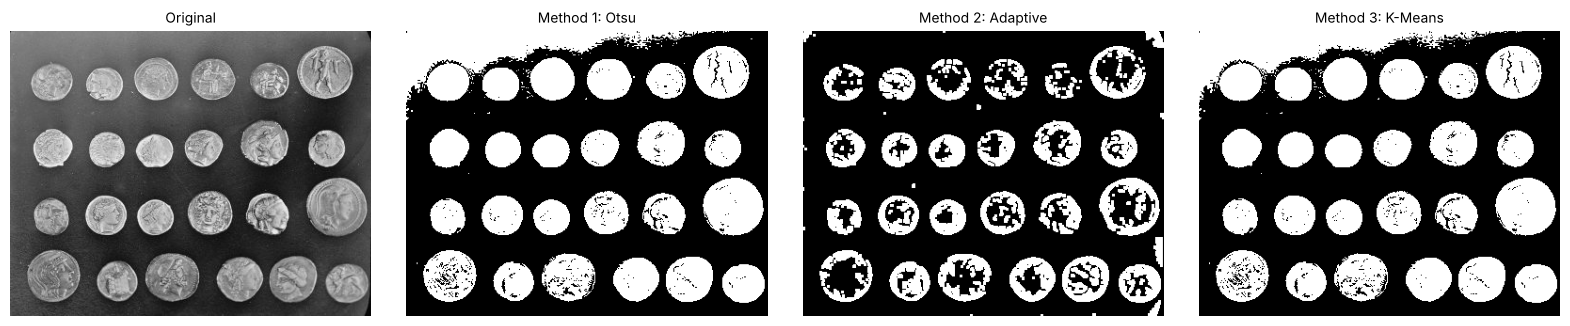

In [12]:
uimg = cv2.imread('data/coins.png', cv2.IMREAD_GRAYSCALE)          # grayscale objects on uneven background
def count(mask, min_area=80):
    n, _, st, _ = cv2.connectedComponentsWithStats(mask); return int((st[1:, cv2.CC_STAT_AREA] >= min_area).sum())

_, m1 = cv2.threshold(uimg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)                       # Method 1 Otsu
m2 = cv2.adaptiveThreshold(uimg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, -5)  # Method 2 adaptive
m2 = cv2.morphologyEx(m2, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
_, lab, cen = cv2.kmeans(np.float32(uimg.reshape(-1, 1)), 2, None, criteria, 10, cv2.KMEANS_PP_CENTERS)  # Method 3 K-means
m3 = (lab.reshape(uimg.shape) == np.argmax(cen)).astype(np.uint8) * 255
for name, m in [('Otsu', m1), ('Adaptive (51, -5)', m2), ('K-Means K=2', m3)]:
    print(f'{name:18s}: objects found = {count(m)} (true = 24 coins)')
show([uimg, m1, m2, m3], ['Original', 'Method 1: Otsu', 'Method 2: Adaptive', 'Method 3: K-Means'])

| Method | Assumption | Succeeds on | Incorrectly segments | Key parameter |
|---|---|---|---|---|
| Otsu | bimodal histogram (coins vs background) | all 24 coins as solid blobs | bright background patch in the top-left corner; dark details inside some coins | none (auto T) – depends on preprocessing |
| Adaptive (51, −5) | object brighter than its **local** neighbourhood | coin outlines everywhere | coin **interiors** break into fragments (36 "objects") because the coin texture is compared to itself | **blockSize** and C |
| K-Means (K=2) | two intensity clusters | same 24 coins as Otsu | same top-left patch | K (and initialisation) |

**Conclusion (from the counts and masks above):** Otsu gave the most meaningful regions (24/24 solid coins) because the histogram is clearly **bimodal** and the lighting variation is mild; adaptive thresholding over-segments textured objects, and K-Means with K=2 reduces to the same split as Otsu.